<a href="https://colab.research.google.com/github/MOISECHRIST/PyTorch_Tutorial/blob/main/ANN/Intro_To_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Deep Learning with Pytorch

## Review of Pytorch

In [1]:
import torch

In [2]:
### Create tensor
my_tensor = torch.arange(10)
my_tensor

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [5]:
### Reshape
my_tensor = my_tensor.reshape(2,5)
my_tensor

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [24]:
my_tensor2 = my_tensor.reshape(-1)
my_tensor2

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [26]:
my_tensor2 = my_tensor.reshape(5,2)
my_tensor2[:,1], my_tensor2

(tensor([1, 3, 5, 7, 9]),
 tensor([[0, 1],
         [2, 3],
         [4, 5],
         [6, 7],
         [8, 9]]))

In [27]:
my_tensor2[:,1:], my_tensor2, my_tensor2[:,1].reshape(-1,1)

(tensor([[1],
         [3],
         [5],
         [7],
         [9]]),
 tensor([[0, 1],
         [2, 3],
         [4, 5],
         [6, 7],
         [8, 9]]),
 tensor([[1],
         [3],
         [5],
         [7],
         [9]]))

In [11]:
### View
my_tensor3 = my_tensor.view(2,5)

In [12]:
my_tensor3

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [13]:
my_tensor3[0,0]=10

In [14]:
my_tensor, my_tensor3

(tensor([[10,  1,  2,  3,  4],
         [ 5,  6,  7,  8,  9]]),
 tensor([[10,  1,  2,  3,  4],
         [ 5,  6,  7,  8,  9]]))

In [18]:
### Clone
my_tensor = torch.arange(10)

my_tensor4 = my_tensor.clone()

In [19]:
my_tensor4[0] = 10
my_tensor4, my_tensor

(tensor([10,  1,  2,  3,  4,  5,  6,  7,  8,  9]),
 tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]))

In [20]:
### Detach
my_tensor = torch.arange(10)

my_tensor4 = my_tensor.detach()

In [21]:
my_tensor4[0] = 10
my_tensor4, my_tensor

(tensor([10,  1,  2,  3,  4,  5,  6,  7,  8,  9]),
 tensor([10,  1,  2,  3,  4,  5,  6,  7,  8,  9]))

In [22]:
### Clone+detach vs detach+clone
my_tensor = torch.arange(10)
my_tensor4 = my_tensor.clone().detach()
my_tensor4[0] = 10
my_tensor4, my_tensor

(tensor([10,  1,  2,  3,  4,  5,  6,  7,  8,  9]),
 tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]))

In [23]:
my_tensor = torch.arange(10)
my_tensor4 = my_tensor.detach().clone()
my_tensor4[0] = 10
my_tensor4, my_tensor

(tensor([10,  1,  2,  3,  4,  5,  6,  7,  8,  9]),
 tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]))

In [31]:
torch.add(my_tensor, my_tensor)

tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [32]:
torch.sub(my_tensor, my_tensor)

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [33]:
torch.mul(my_tensor, my_tensor)

tensor([ 0,  1,  4,  9, 16, 25, 36, 49, 64, 81])

In [34]:
torch.matmul(my_tensor, my_tensor.reshape(-1,1))

tensor([285])

## Simple Perceptron

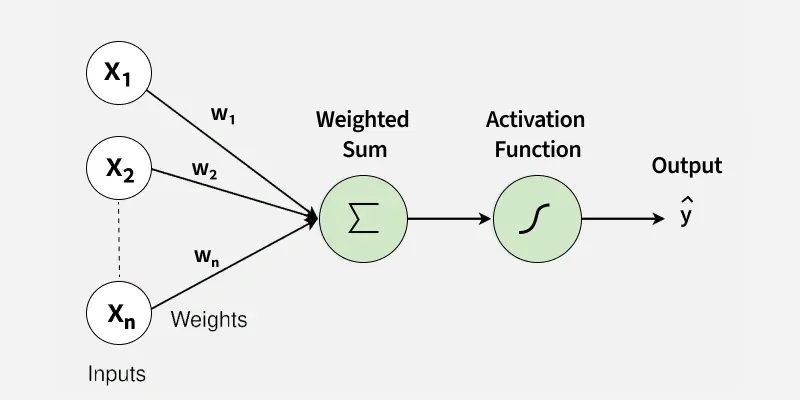

In [64]:
import torch
from torch import nn
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

### Load data and Process

In [37]:
path = kagglehub.dataset_download("arshid/iris-flower-dataset")

100%|██████████| 0.99k/0.99k [00:00<00:00, 1.24MB/s]

Extracting files...


In [42]:
os.listdir(path)

['IRIS.csv']

In [112]:
iris = pd.read_csv(os.path.join(path, os.listdir(path)[0]))

In [97]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


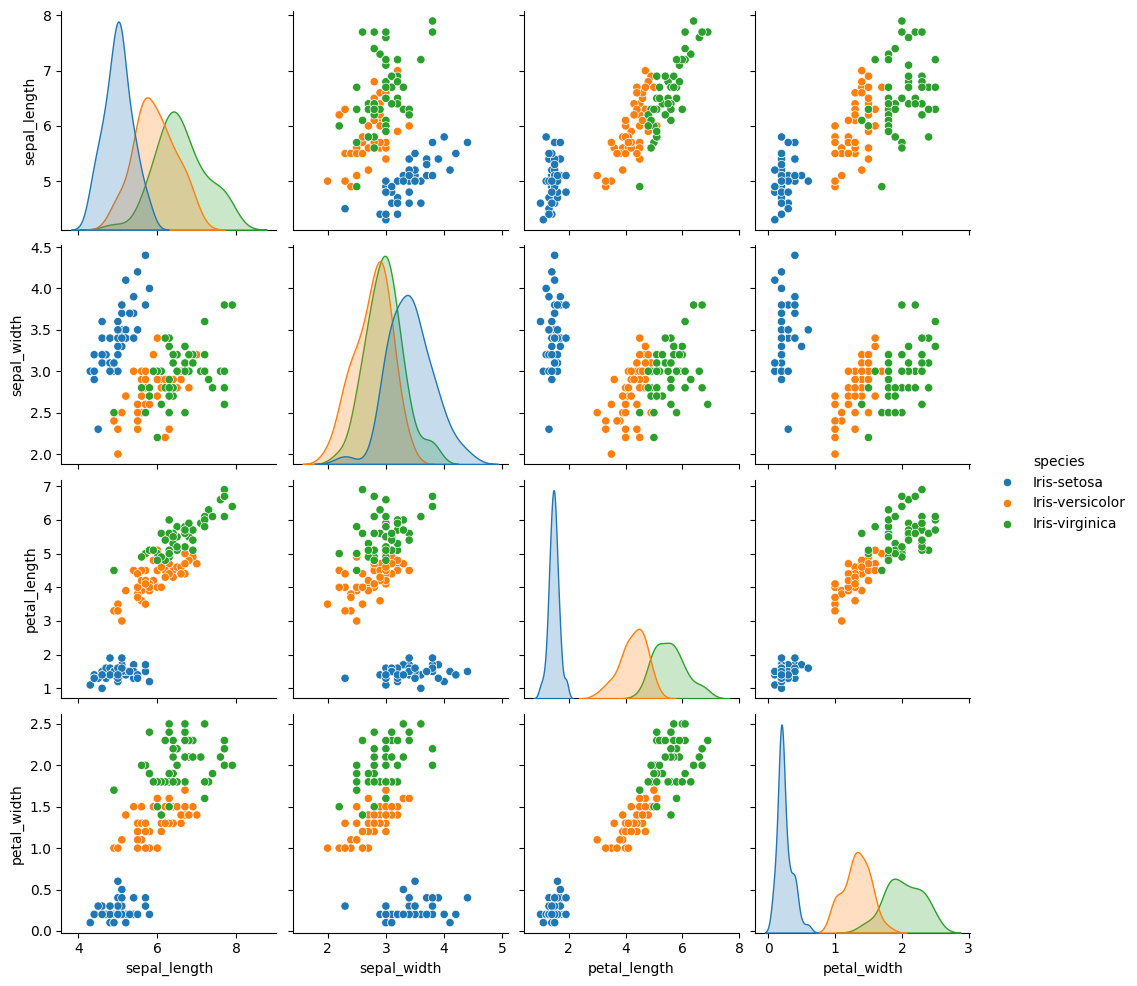

In [98]:
sns.pairplot(iris, hue="species")

In [113]:
X = torch.FloatTensor(iris.drop('species', axis=1).values)
X.shape

torch.Size([150, 4])

In [114]:
map_dict = {'Iris-setosa':0, 'Iris-versicolor':1, 'Iris-virginica':2}
encode_species = lambda x : map_dict[x]
iris["species_encoding"] = iris['species'].apply(encode_species)

In [115]:
Y = nn.functional.one_hot(torch.from_numpy(iris["species_encoding"].values)).float()

In [116]:
X.shape, Y.shape

(torch.Size([150, 4]), torch.Size([150, 3]))

In [117]:
X_train,  X_test_val, Y_train, Y_test_val = train_test_split(X, Y, train_size=0.7)
X_test, X_val, Y_test, Y_val = train_test_split(X_test_val, Y_test_val, train_size=0.5)

N = X.shape[0]
print(f"Train set : {X_train.shape[0]} ({100*X_train.shape[0]/N:.2f}%)")
print(f"Test set : {X_test.shape[0]} ({100*X_test.shape[0]/N:.2f}%)")
print(f"Valid set : {X_val.shape[0]} ({100*X_val.shape[0]/N:.2f}%)")

Train set : 105 (70.00%)
Test set : 22 (14.67%)
Valid set : 23 (15.33%)


### Create the model

In [196]:
class Perceptron(nn.Module):
  '''
  Simple Perceptron with multiple neurones (Linear -> Sigmoid),

  then Softmax to normalize probabilities
  '''
  def __init__(self, input_features=4, out_features=3):
    super().__init__()
    self.weigthed_sum = nn.Linear(input_features, out_features)
    self.activation = nn.Sigmoid()
    self.prob = nn.Softmax()

  def forward(self, X):
    X = self.weigthed_sum(X)
    X = self.activation(X)
    return self.prob(X)


In [197]:
torch.manual_seed(41)
model = Perceptron()

In [215]:
model

Perceptron(
  (weigthed_sum): Linear(in_features=4, out_features=3, bias=True)
  (activation): Sigmoid()
  (prob): Softmax(dim=None)
)

### Loss function and Optimizer

In [199]:
# Loss function
loss_func = nn.CrossEntropyLoss()

# Optimizer
lr = 0.01
optimizer = torch.optim.Adam(model.parameters(),lr = lr)

### Train our model

In [200]:
def compute_accuracy(y_hat, y_true):
  N = y_hat.shape[0]
  class_matches = torch.argmax(y_true, axis=1) == torch.argmax(y_hat, axis=1)
  return torch.sum(class_matches)/N

In [201]:
epoch_nb = 100

hist = {'train_loss':[],
        'train_acc':[],
        'valid_loss':[],
        'valid_acc':[]}
for epoch in range(epoch_nb):
  ## Set a model to train mode
  model.train()

  ## Initialize gradient
  optimizer.zero_grad()

  ## Forward propagation
  y_train_hat = model(X_train)

  ## Loss evaluation
  loss = loss_func(y_train_hat, Y_train)

  ## Store loss value
  hist['train_loss'].append(loss.item())

  ## Store accuracy
  hist['train_acc'].append(compute_accuracy(y_train_hat, Y_train).item())

  ## Backward propagation
  loss.backward()

  ## Update model weights
  optimizer.step()


  ## Validate the training
  model.eval()
  with torch.inference_mode():
    y_val_hat = model(X_val)
    loss = loss_func(y_val_hat, Y_val)
    hist['valid_loss'].append(loss.detach().numpy())
    hist['valid_acc'].append(compute_accuracy(y_val_hat, Y_val).detach().numpy())

    ## Print training process
    if epoch % 5 ==0:
      print(f"Epoch {epoch} -------------------------------------------")
      print(f" ->Loss TrainSet = {hist['train_loss'][-1]:.4f} Acc TrainSet = {hist['train_acc'][-1]:.4f}")
      print(f" ->Loss ValidSet = {hist['valid_loss'][-1]:.4f} Acc ValidSet = {hist['valid_acc'][-1]:.4f}")

Epoch 0 -------------------------------------------
 ->Loss TrainSet = 1.0992 Acc TrainSet = 0.3619
 ->Loss ValidSet = 1.1286 Acc ValidSet = 0.2609
Epoch 5 -------------------------------------------
 ->Loss TrainSet = 1.0927 Acc TrainSet = 0.3619
 ->Loss ValidSet = 1.1233 Acc ValidSet = 0.2609
Epoch 10 -------------------------------------------
 ->Loss TrainSet = 1.0865 Acc TrainSet = 0.3619
 ->Loss ValidSet = 1.1184 Acc ValidSet = 0.2609
Epoch 15 -------------------------------------------
 ->Loss TrainSet = 1.0793 Acc TrainSet = 0.3619
 ->Loss ValidSet = 1.1135 Acc ValidSet = 0.2609
Epoch 20 -------------------------------------------
 ->Loss TrainSet = 1.0704 Acc TrainSet = 0.3619
 ->Loss ValidSet = 1.1078 Acc ValidSet = 0.2609
Epoch 25 -------------------------------------------
 ->Loss TrainSet = 1.0601 Acc TrainSet = 0.3714
 ->Loss ValidSet = 1.1015 Acc ValidSet = 0.3043
Epoch 30 -------------------------------------------
 ->Loss TrainSet = 1.0492 Acc TrainSet = 0.7048
 ->Loss

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1776: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


In [202]:
#Visualize training
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter)

def plot_results(metrics, title=None, ylabel=None, ylim=None, metric_name=None, color=None, epoch_nb=100):

    fig, ax = plt.subplots(figsize=(15, 4))

    if not (isinstance(metric_name, list) or isinstance(metric_name, tuple)):
        metrics = [metrics,]
        metric_name = [metric_name,]

    for idx, metric in enumerate(metrics):
        ax.plot(metric, color=color[idx])

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xlim([0, epoch_nb])
    plt.ylim(ylim)
    # Tailor x-axis tick marks
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    plt.grid(True)
    plt.legend(metric_name)
    plt.show()
    plt.close()

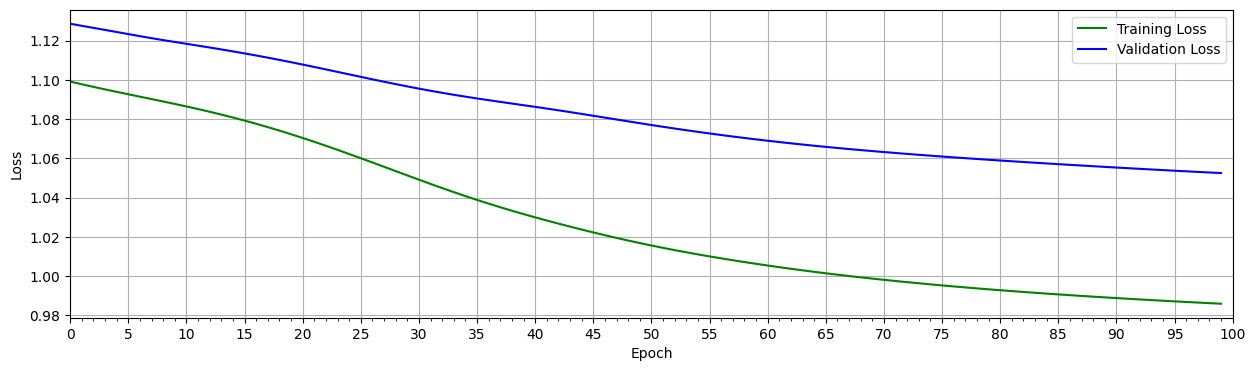

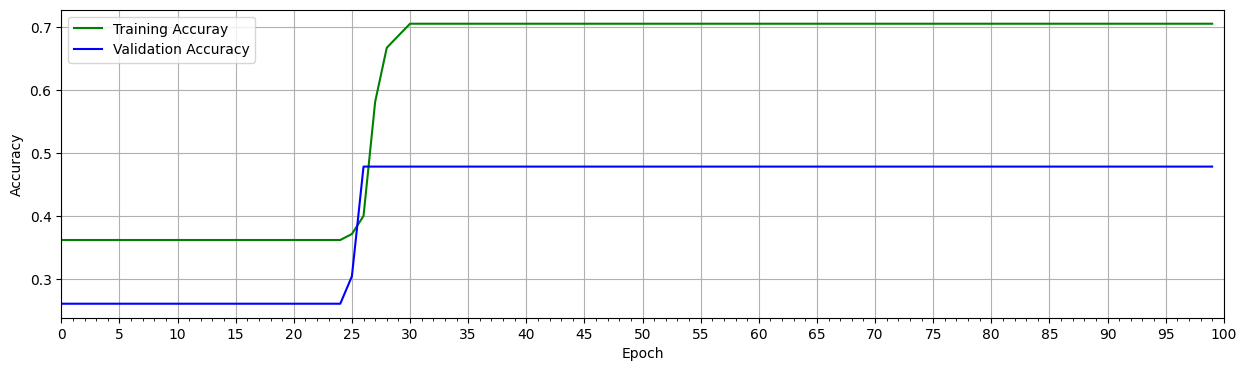

In [203]:
plot_results([ hist['train_loss'], hist['valid_loss'] ],
            ylabel="Loss",
            metric_name=["Training Loss", "Validation Loss"],
            color=["g", "b"], epoch_nb=epoch_nb)
plot_results([ hist['train_acc'], hist['valid_acc'] ],
            ylabel="Accuracy",
            metric_name=["Training Accuray", "Validation Accuracy"],
            color=["g", "b"], epoch_nb=epoch_nb)

In [204]:
y_pred = model(X_test)
print(f"Accuracy on test set = {compute_accuracy(y_pred, Y_test).item():.4f}")

Accuracy on test set = 0.6818


## Multilayer Perceptron

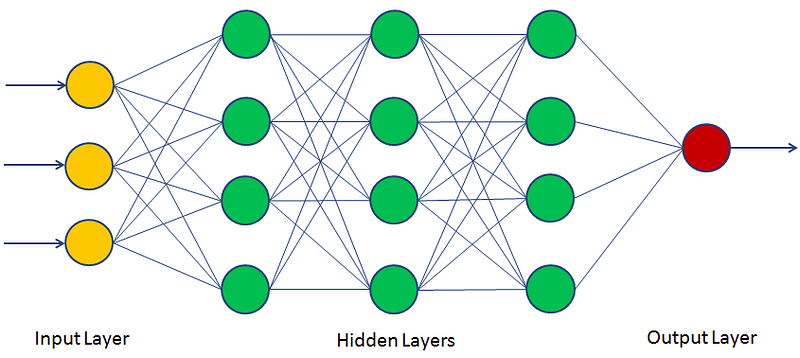

In [212]:
class MultiLayerPerceptron(nn.Module):
  def __init__(self, input_features=4, out_features=3, nb_hidden_layers=1, neurones_per_layer=10):
    super().__init__()
    self.sequence = nn.Sequential(nn.Linear(input_features, neurones_per_layer),
                                   nn.ReLU())
    for i in range(nb_hidden_layers):
      self.sequence.append(nn.Linear(neurones_per_layer, neurones_per_layer))
      self.sequence.append(nn.ReLU())
    self.sequence.append(nn.Linear(neurones_per_layer, out_features))
    self.sequence.append(nn.ReLU())
    self.sequence.append(nn.Softmax())
  def forward(self, X):
    X = self.sequence(X)
    return X

model2 = MultiLayerPerceptron()

In [213]:
model2

MultiLayerPerceptron(
  (sequence): Sequential(
    (0): Linear(in_features=4, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=3, bias=True)
    (5): ReLU()
    (6): Softmax(dim=None)
  )
)

In [216]:
learning_rate = 0.01

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2.parameters(),lr=learning_rate)

In [219]:
def training_loop(model, loss_func, optimizer, train_set, valid_set = None, epoch_nb=100):
  hist = {'train_loss':[],
          'train_acc':[]}
  X_train, Y_train = train_set

  if valid_set != None:
    hist['valid_loss']=[]
    hist['valid_acc']=[]
    X_val, Y_val = valid_set

  for epoch in range(epoch_nb):
    ## Set a model to train mode
    model.train()

    ## Initialize gradient
    optimizer.zero_grad()

    ## Forward propagation
    y_train_hat = model(X_train)

    ## Loss evaluation
    loss = loss_func(y_train_hat, Y_train)

    ## Store loss value
    hist['train_loss'].append(loss.item())

    ## Store accuracy
    hist['train_acc'].append(compute_accuracy(y_train_hat, Y_train).item())

    ## Backward propagation
    loss.backward()

    ## Update model weights
    optimizer.step()

    ## Print training process
    print(f"Epoch {epoch} -------------------------------------------")
    print(f" ->Loss TrainSet = {hist['train_loss'][-1]:.4f} Acc TrainSet = {hist['train_acc'][-1]:.4f}")

    ## Validate the training
    if valid_set != None:
      model.eval()
      with torch.inference_mode():
        y_val_hat = model(X_val)
        loss = loss_func(y_val_hat, Y_val)
        hist['valid_loss'].append(loss.detach().numpy())
        hist['valid_acc'].append(compute_accuracy(y_val_hat, Y_val).detach().numpy())

        print(f" ->Loss ValidSet = {hist['valid_loss'][-1]:.4f} Acc ValidSet = {hist['valid_acc'][-1]:.4f}")
  return hist

In [220]:
hist = training_loop(model2, loss_func, optimizer, (X_train, Y_train),
                     (X_val, Y_val))

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1776: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Epoch 0 -------------------------------------------
 ->Loss TrainSet = 1.0862 Acc TrainSet = 0.4000
 ->Loss ValidSet = 1.0732 Acc ValidSet = 0.4783
Epoch 1 -------------------------------------------
 ->Loss TrainSet = 1.0659 Acc TrainSet = 0.6952
 ->Loss ValidSet = 1.0717 Acc ValidSet = 0.4783
Epoch 2 -------------------------------------------
 ->Loss TrainSet = 1.0501 Acc TrainSet = 0.7048
 ->Loss ValidSet = 1.0673 Acc ValidSet = 0.4783
Epoch 3 -------------------------------------------
 ->Loss TrainSet = 1.0349 Acc TrainSet = 0.7048
 ->Loss ValidSet = 1.0626 Acc ValidSet = 0.4783
Epoch 4 -------------------------------------------
 ->Loss TrainSet = 1.0219 Acc TrainSet = 0.7048
 ->Loss ValidSet = 1.0582 Acc ValidSet = 0.4783
Epoch 5 -------------------------------------------
 ->Loss TrainSet = 1.0088 Acc TrainSet = 0.7048
 ->Loss ValidSet = 1.0537 Acc ValidSet = 0.4783
Epoch 6 -------------------------------------------
 ->Loss TrainSet = 0.9949 Acc TrainSet = 0.7048
 ->Loss Vali

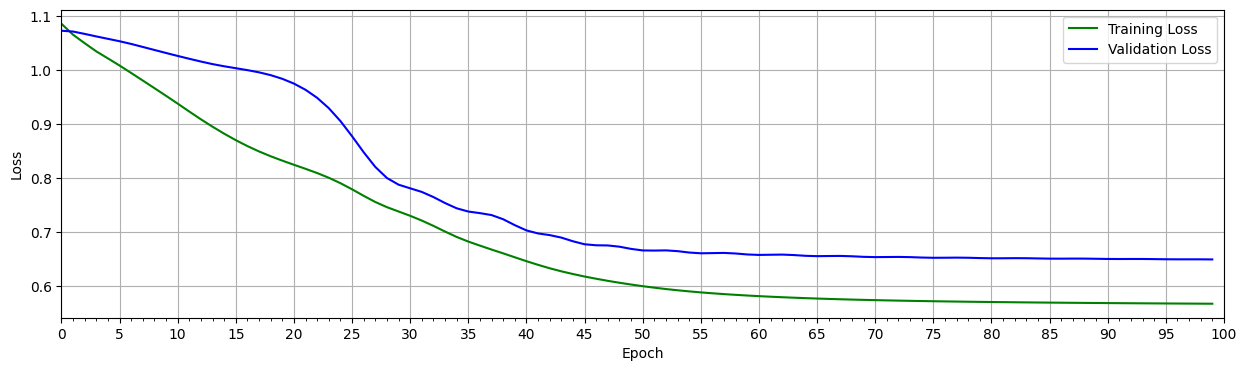

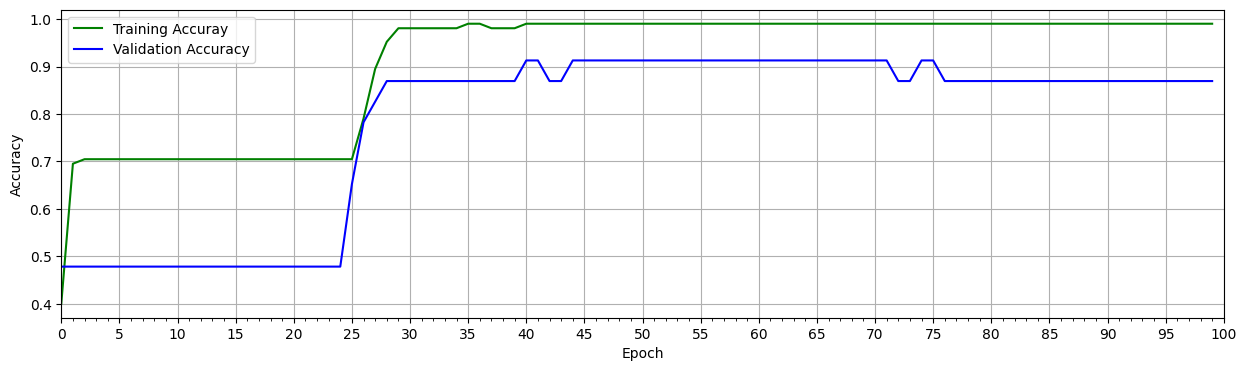

In [221]:
plot_results([ hist['train_loss'], hist['valid_loss'] ],
            ylabel="Loss",
            metric_name=["Training Loss", "Validation Loss"],
            color=["g", "b"], epoch_nb=epoch_nb)
plot_results([ hist['train_acc'], hist['valid_acc'] ],
            ylabel="Accuracy",
            metric_name=["Training Accuray", "Validation Accuracy"],
            color=["g", "b"], epoch_nb=epoch_nb)

In [223]:
y_pred = model2(X_test)
print(f"Accuracy on test set = {compute_accuracy(y_pred, Y_test).item()}")

Accuracy on test set = 1.0


In [227]:
pred = model2(X)
print(f"Accuracy on test set = {compute_accuracy(pred, Y)}")

Accuracy on test set = 0.9733333587646484


In [230]:
150-150*0.9733333587646484

3.9999961853027344

In [238]:
iris["pred_class"] = torch.argmax(pred, axis=1)
iris["match_class"] = iris['species_encoding']

iris.loc[iris['species_encoding'] != iris['pred_class'], 'match_class'] = 4

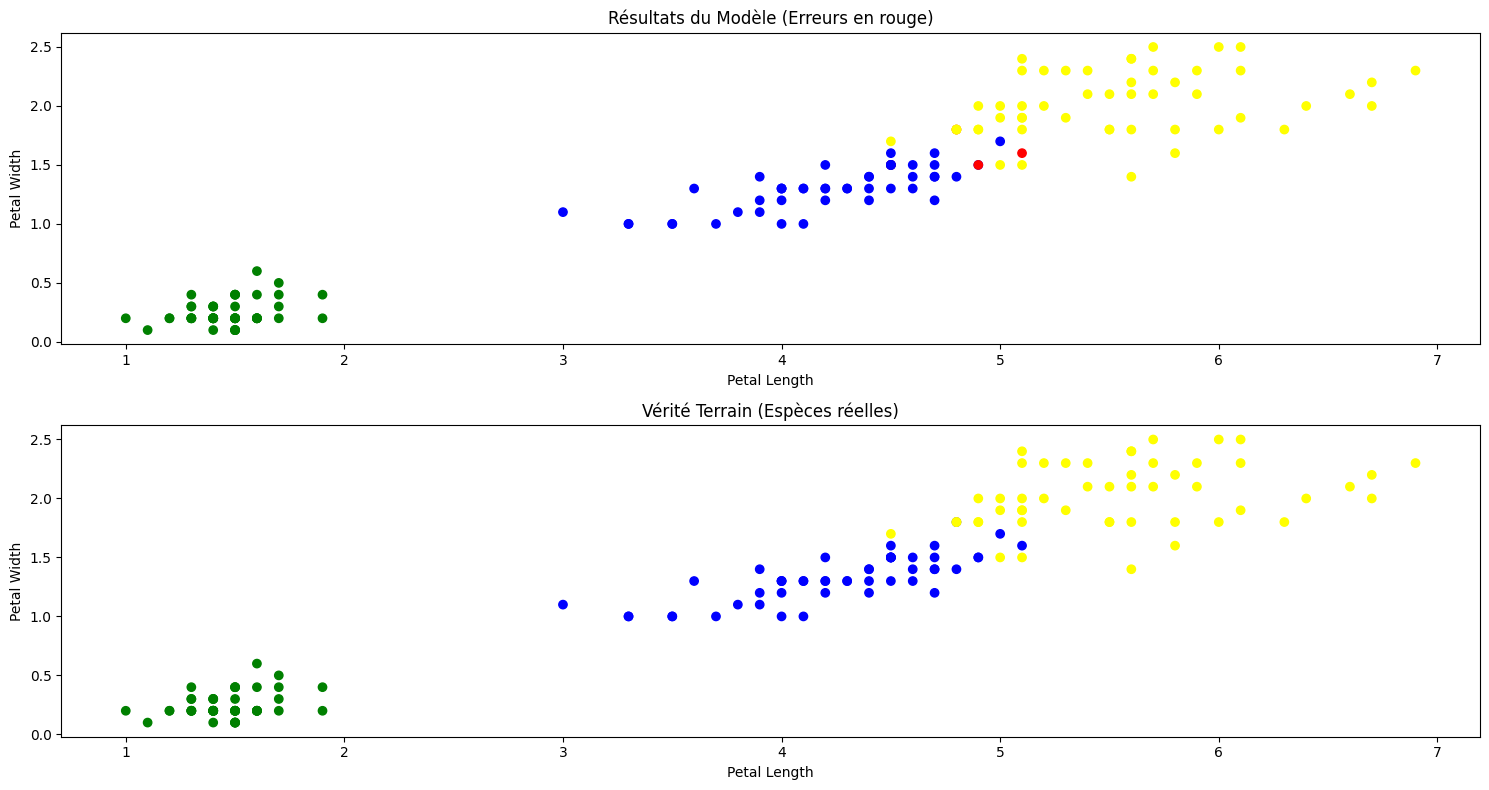

In [243]:
from matplotlib.colors import ListedColormap

custom_cmap_match = ListedColormap(['green', 'blue', 'yellow', 'red'])
custom_cmap_species = ListedColormap(['green', 'blue', 'yellow'])

plt.figure(figsize=(15, 8))


plt.subplot(2, 1, 1)
plt.scatter(iris['petal_length'], iris['petal_width'], c=iris['match_class'], cmap=custom_cmap_match)
plt.title('Résultats du Modèle (Erreurs en rouge)')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')


plt.subplot(2, 1, 2)
plt.scatter(iris['petal_length'], iris['petal_width'], c=iris['species_encoding'], cmap=custom_cmap_species)
plt.title('Vérité Terrain (Espèces réelles)')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')

plt.tight_layout()
plt.show()